PART 0: Setup Reminder

Activation of Venv and installation of SkLearn
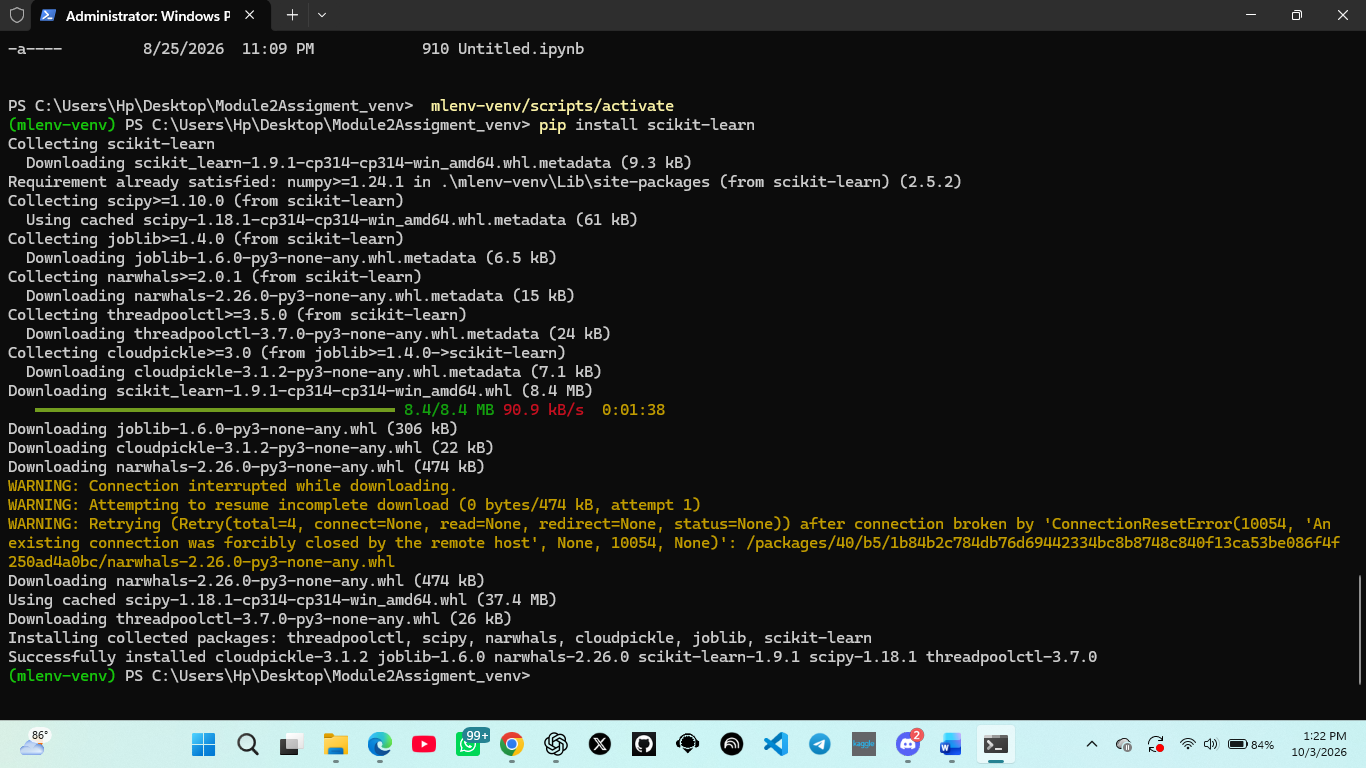

Verifing the Package Installed
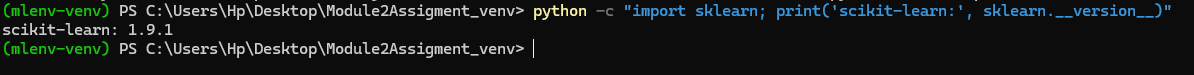

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

PART 1 — Load & Explore the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
 
%matplotlib inline
sns.set_style('whitegrid')

Task 1:  Load the dataset into a DataFrame and print its shape and column names

In [2]:
df = pd.read_csv('USA_Housing.csv')
print(df.shape)
print(df.columns.tolist())

(5000, 7)
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']


Task 2:  Display the first 5 rows, then run df.info() and df.describe()

In [3]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 499.6 KB


In [5]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


Task 3:  Check for missing values in every column

In [6]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Task 4:  Drop the Address column — it isn't useful for a numeric regression model

In [7]:
df = df.drop('Address', axis=1)
print(df.columns.tolist())

['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price']


Task 5:  Create a heatmap of the correlation between all numeric columns, including Price

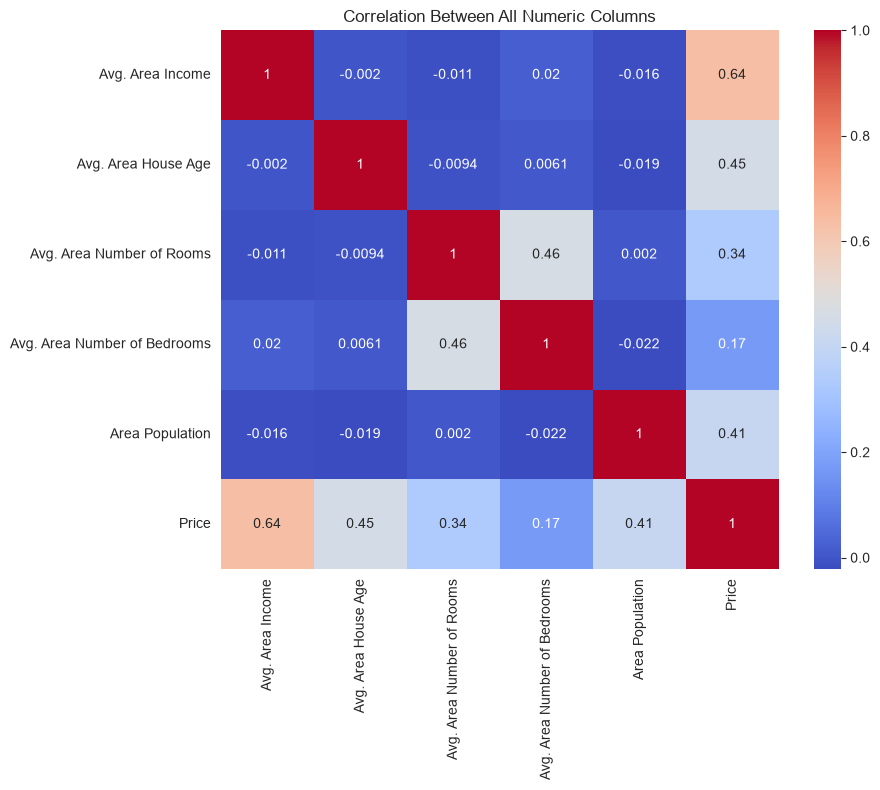

In [8]:
plt.figure(figsize=(9, 7))
# Your heatmap code here
# Hint: sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between All Numeric Columns')
plt.show()

Observation From Part 1:

'Avg.Area Income' has the strongest positive correlation with 'Price' while 'Avg.Area Number of Bedrooms' has the weakest positive correlation with 'Price'.

therefore, 'Avg.Area Income' having the strongest positive correlation with the target variable (Price), is the feature that will matter most for prediction.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

PART 2 — Simple Linear Regression

Task 1:  Select Avg. Area Income as X and Price as y

In [9]:
X = df[['Avg. Area Income']]
y = df['Price']

Task 2:  Split the data into training and test sets (80% train, 20% test)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 
print('Train size:', X_train.shape[0]) 
print('Test size:', X_test.shape[0]) 

Train size: 4000
Test size: 1000


Task 3:  Create and fit a LinearRegression model on the training data

In [11]:
model_simple = LinearRegression() 
model_simple.fit(X_train, y_train) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[21.21]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Avg. Area Income']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.251e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


Task 4:  Predict on the test set, then plot actual vs. predicted values as a scatter plot

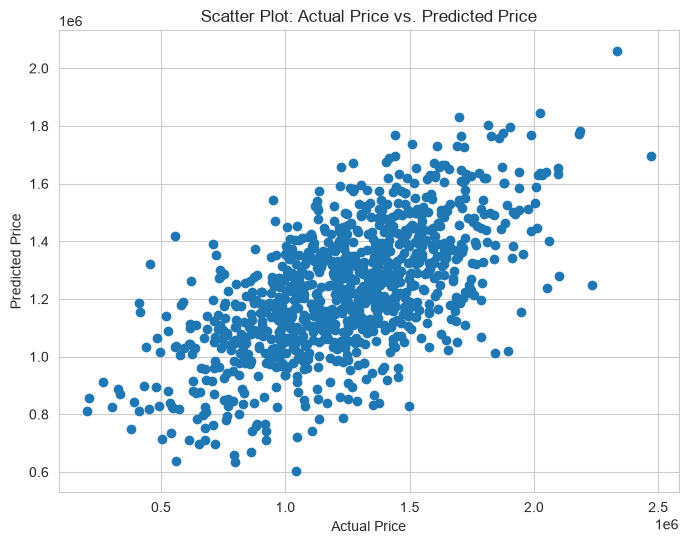

In [14]:
y_pred_simple = model_simple.predict(X_test) 
  
plt.figure(figsize=(8, 6)) 
# Your scatter plot code here 
# Hint: plt.scatter(y_test, y_pred_simple) 
plt.scatter(y_test, y_pred_simple)
plt.xlabel('Actual Price') 
plt.ylabel('Predicted Price') 
plt.title('Scatter Plot: Actual Price vs. Predicted Price') 
plt.show() 

Task 5:  Print the model's coefficient and intercept. In a Markdown cell, explain in plain words what 
the coefficient means

In [15]:
print('Coefficient:', model_simple.coef_[0]) 
print('Intercept:', model_simple.intercept_) 

Coefficient: 21.208906292657534
Intercept: -225053.70287170308


Observation From Part 2:

According to this model, for every $$1 increase in the Average Area Income, there is a predicted house price change of approximately $21.21.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

PART 3 — Multiple Linear Regression 

Task 1:  Select all numeric feature columns (everything except Price) as X, and Price as y

In [16]:
X_multi = df.drop('Price', axis=1) 
y_multi = df['Price']

Task 2:  Split into training and test sets (80/20), using the same random_state=42 as before

In [18]:
X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42) 
print('Train size:', X_multi_train.shape[0]) 
print('Test size:', X_multi_test.shape[0]) 

Train size: 4000
Test size: 1000


Task 3:  Create and fit a LinearRegression model on the training data

In [20]:
model_multi = LinearRegression() 
model_multi.fit(X_multi_train, y_multi_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 21.65,164666.48,119624.01, 2440.38, 15.27]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Avg. Area Income','Avg. Area House Age','Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms','Area Population']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.635e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


Task 4:  Predict on the test set. 

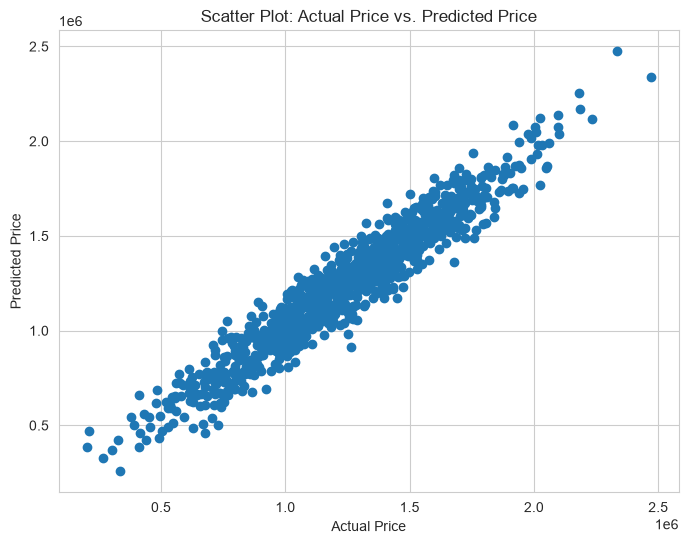

In [21]:
y_pred_multi = model_multi.predict(X_multi_test) 
  
plt.figure(figsize=(8, 6)) 
# Your scatter plot code here 
# Hint: plt.scatter(y_multi_test, y_pred_multi) 
plt.scatter(y_multi_test, y_pred_multi)
plt.xlabel('Actual Price') 
plt.ylabel('Predicted Price') 
plt.title('Scatter Plot: Actual Price vs. Predicted Price') 
plt.show() 

Task 5:  Print the coefficient for each feature next to its column name. Which feature has the 
largest effect on price?

In [22]:
coeff_df = pd.DataFrame( 
model_multi.coef_, X_multi.columns, columns=['Coefficient'] 
) 
print(coeff_df)

                                Coefficient
Avg. Area Income                  21.652206
Avg. Area House Age           164666.480722
Avg. Area Number of Rooms     119624.012232
Avg. Area Number of Bedrooms    2440.377611
Area Population                   15.270313


Observation From Part 3:

The largest coefficient is for Avg. Area House Age (164,666.48). However, this does not necessarily mean it is the most important feature because the features are measured on different scales and units. A coefficient represents the predicted change in house price for a one-unit increase in that particular feature, while holding the other features constant. Therefore, raw coefficient magnitudes should not be directly compared to determine feature importance.

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

PART 4 — Evaluating & Comparing Both Models

Task 1:  Calculate MAE, MSE, RMSE, and R² for the simple regression model (Part 2)

In [23]:
mae_simple = metrics.mean_absolute_error(y_test, y_pred_simple) 
mse_simple = metrics.mean_squared_error(y_test, y_pred_simple) 
rmse_simple = np.sqrt(mse_simple) 
r2_simple = metrics.r2_score(y_test, y_pred_simple) 
  
print('MAE:', mae_simple) 
print('MSE:', mse_simple) 
print('RMSE:', rmse_simple) 
print('R2:', r2_simple) 

MAE: 216826.35309989064
MSE: 74194887058.66
RMSE: 272387.38417676394
R2: 0.39694865192619766


Task 2:  Calculate the same four metrics for the multiple regression model (Part 3)

In [24]:
mae_multi = metrics.mean_absolute_error(y_multi_test, y_pred_multi) 
mse_multi = metrics.mean_squared_error(y_multi_test, y_pred_multi) 
rmse_multi = np.sqrt(mse_multi) 
r2_multi = metrics.r2_score(y_multi_test, y_pred_multi) 
  
print('MAE:', mae_multi) 
print('MSE:', mse_multi) 
print('RMSE:', rmse_multi) 
print('R2:', r2_multi) 

MAE: 80879.09723487176
MSE: 10089009300.89096
RMSE: 100444.06055556974
R2: 0.9179971706834578


Task 3:  Build a small comparison table (as a DataFrame) showing both models' metrics side by 
side

In [25]:
comparison = pd.DataFrame({ 
    'Simple (Income only)': [mae_simple, mse_simple, rmse_simple, r2_simple], 
    'Multiple (All features)': [mae_multi, mse_multi, rmse_multi, r2_multi] 
}, index=['MAE', 'MSE', 'RMSE', 'R2']) 
print(comparison)

      Simple (Income only)  Multiple (All features)
MAE           2.168264e+05             8.087910e+04
MSE           7.419489e+10             1.008901e+10
RMSE          2.723874e+05             1.004441e+05
R2            3.969487e-01             9.179972e-01


Task 4:  Plot a histogram of the residuals (y_test − predictions) for the multiple regression model. 
Check whether they look roughly normally distributed

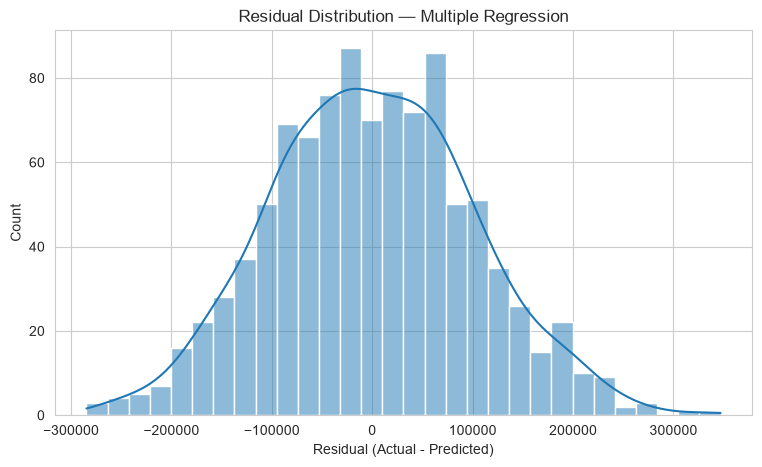

In [28]:
residuals = y_multi_test - y_pred_multi 
plt.figure(figsize=(9, 5)) 
# Your histogram code here
sns.histplot(residuals, bins=30, kde=True)
plt.title('Residual Distribution — Multiple Regression') 
plt.xlabel('Residual (Actual - Predicted)') 
plt.show() 

Observation From Part 4:

The Multiple Linear Regression model performed better than the Simple Linear Regression model because it had lower MAE, MSE, and RMSE, while achieving a higher R². The MAE decreased from 216,826.40USD to 80,879.10USD, while the RMSE decreased from 272,387.40USD to 100,444.10USD. The R² increased from 0.3969 to 0.9180, meaning the multiple regression model explains substantially more of the variation in house prices. Therefore, adding the additional features was beneficial for this dataset. The residual histogram appears approximately bell-shaped and centered around zero, suggesting that the residuals are approximately normally distributed

-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Part 5 — Bonus: Polynomial Regression

Task 1:  Using only Avg. Area Income, create degree-2 polynomial features

In [30]:
from sklearn.preprocessing import PolynomialFeatures 
poly = PolynomialFeatures(degree=2) 
X_poly = poly.fit_transform(X) 

Task 2:  Split, fit a LinearRegression model on the polynomial features, and calculate its R² score

In [31]:
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)
print('Train size:', X_train_poly.shape[0]) 
print('Test size:', X_test_poly.shape[0])

Train size: 4000
Test size: 1000


In [32]:
# Train the PPolynomial Regression 
model_poly = LinearRegression()

model_poly.fit(X_train_poly, y_train_poly)

y_pred_poly = model_poly.predict(X_test_poly)

In [33]:
# Calculate R-squared score
r2_poly = metrics.r2_score(y_test_poly, y_pred_poly)

print("Polynomial Regression R²:", r2_poly)
print("Simple Linear Regression R²:", r2_simple)

Polynomial Regression R²: 0.3939626768410842
Simple Linear Regression R²: 0.39694865192619766


Task 3:  Compare this R² score to the simple linear regression R² from Part 2. Did the curve 
improve the fit?

In [34]:
print("Polynomial Regression R²:", r2_poly)
print("Simple Linear Regression R²:", r2_simple)

if r2_poly > r2_simple:
    print("Polynomial regression improved the fit.")
elif r2_poly < r2_simple:
    print("Polynomial regression did not improve the fit.")
else:
    print("Both models have the same R².")

Polynomial Regression R²: 0.3939626768410842
Simple Linear Regression R²: 0.39694865192619766
Polynomial regression did not improve the fit.


Observation From Part 5:

Polynomial regression did not improve the model compared with simple linear regression for Avg. Area Income. The simple linear regression achieved an R² of 0.3969, while the degree-2 polynomial regression achieved an R² of 0.3940. The slight decrease in R² suggests that adding a quadratic term did not provide a better fit for this feature on the test data. This may be because the relationship between average area income and house price is approximately linear, so adding a curve did not provide additional predictive value.
